In [1]:
import pandas as pd

def load_csv(file):
    try:
        return pd.read_csv(file, engine="python", on_bad_lines="skip", encoding="utf-8")
    except:
        return pd.read_csv(file, engine="python", on_bad_lines="skip", encoding="latin1")

orders = load_csv("orders_dataset.csv")
order_items = load_csv("order_items_dataset.csv")
payments = load_csv("order_payments_dataset.csv")
reviews = load_csv("order_reviews_dataset.csv")
products = load_csv("products_dataset.csv")

## Features Engineering




In [2]:
data = orders.copy()

# revenue
payment_per_order = payments.groupby('order_id')['payment_value'].sum().reset_index()
data = data.merge(payment_per_order, on='order_id', how='left')

# num_products
num_products = order_items.groupby('order_id')['product_id'].count().reset_index()
num_products.rename(columns={'product_id': 'num_products_sold'}, inplace=True)
data = data.merge(num_products, on='order_id', how='left')

# avg_price
avg_price = order_items.groupby('order_id')['price'].mean().reset_index()
avg_price.rename(columns={'price': 'avg_price'}, inplace=True)
data = data.merge(avg_price, on='order_id', how='left')

# total_price
total_price = order_items.groupby('order_id')['price'].sum().reset_index()
total_price.rename(columns={'price': 'total_price'}, inplace=True)
data = data.merge(total_price, on='order_id', how='left')

# review_score
review = reviews.groupby('order_id')['review_score'].mean().reset_index()
data = data.merge(review, on='order_id', how='left')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  object 
 1   customer_id                    99441 non-null  object 
 2   order_status                   99441 non-null  object 
 3   order_purchase_timestamp       99441 non-null  object 
 4   order_approved_at              99281 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  99441 non-null  object 
 8   payment_value                  99440 non-null  float64
 9   num_products_sold              98666 non-null  float64
 10  avg_price                      98666 non-null  float64
 11  total_price                    98666 non-null  float64
 12  review_score                   98673 non-null 

##Handle the Missing Values

In [4]:
# target
data = data.dropna(subset=['payment_value'])

# rename target
data.rename(columns={'payment_value': 'revenue'}, inplace=True)

# fill features
data['num_products_sold'] = data['num_products_sold'].fillna(0)
data['avg_price'] = data['avg_price'].fillna(data['avg_price'].median())
data['total_price'] = data['total_price'].fillna(data['total_price'].median())
data['review_score'] = data['review_score'].fillna(data['review_score'].median())

##Deal with date values


In [5]:
data['order_purchase_timestamp'] = pd.to_datetime(data['order_purchase_timestamp'])
data['order_delivered_customer_date'] = pd.to_datetime(data['order_delivered_customer_date'])

data['delivery_time'] = (
    data['order_delivered_customer_date'] - data['order_purchase_timestamp']
).dt.days

data['delivery_time'] = data['delivery_time'].fillna(data['delivery_time'].median())

data['day_of_week'] = data['order_purchase_timestamp'].dt.dayofweek
data['month'] = data['order_purchase_timestamp'].dt.month

##Prepare Text Features


In [6]:
text_data = reviews[['order_id', 'review_comment_message']].copy()

# indicator feature
text_data['has_review'] = text_data['review_comment_message'].notnull().astype(int)

# fill text
text_data['review_comment_message'] = text_data['review_comment_message'].fillna("")

# clean text
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

text_data['clean_review'] = text_data['review_comment_message'].apply(clean_text)

# review length
text_data['review_length'] = text_data['clean_review'].apply(lambda x: len(x.split()))

#Create Sentiment

In [7]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.0 MB/s eta 0:00:00


In [8]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

text_data['sentiment_score'] = text_data['clean_review'].apply(
    lambda x: analyzer.polarity_scores(x)['compound']
)

#creat is_positive
text_data['is_positive'] = text_data['sentiment_score'].apply(lambda x: 1 if x > 0 else 0)

In [9]:
#Merge Text data with financial data
text_features = text_data.groupby('order_id').agg({
    'sentiment_score': 'mean',
    'review_length': 'mean',
    'is_positive': 'mean',
    'has_review': 'mean'
}).reset_index()

data = data.merge(text_features, on='order_id', how='left')

# fill NLP
data[['sentiment_score','review_length','is_positive','has_review']] = \
data[['sentiment_score','review_length','is_positive','has_review']].fillna(0)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99440 entries, 0 to 99439
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99440 non-null  object        
 1   customer_id                    99440 non-null  object        
 2   order_status                   99440 non-null  object        
 3   order_purchase_timestamp       99440 non-null  datetime64[ns]
 4   order_approved_at              99280 non-null  object        
 5   order_delivered_carrier_date   97657 non-null  object        
 6   order_delivered_customer_date  96475 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99440 non-null  object        
 8   revenue                        99440 non-null  float64       
 9   num_products_sold              99440 non-null  float64       
 10  avg_price                      99440 non-null  float64       
 11  total_price    

In [11]:
missing = data.isnull().sum()


In [12]:
missing


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0
revenue,0
num_products_sold,0


##Ptepare data for the model

In [16]:
#Selected Feature
features = [
    'num_products_sold',
    'avg_price',
    'review_score',
    'delivery_time',
    'day_of_week',
    'month',

    # NLP
    'sentiment_score',
    'review_length',
    'is_positive',
    'has_review'
]

X = data[features]
y = data['revenue']

In [17]:
#Feature Scalling
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##ML Models

In [19]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

rf = RandomForestRegressor(n_estimators=300, max_depth=15)
gb = GradientBoostingRegressor(n_estimators=200)
xgb = XGBRegressor(n_estimators=400, learning_rate=0.03, max_depth=8)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
xgb.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

In [23]:
#LinearRegression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

##Deep learning


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model_ann = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

model_ann.compile(optimizer='adam', loss='mse')

model_ann.fit(X_train, y_train, epochs=20, batch_size=128, verbose=1)

y_pred_ann = model_ann.predict(X_test).flatten()

Epoch 1/20
622/622 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 25707.6953
Epoch 2/20
622/622 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6567.1426
Epoch 3/20
622/622 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6045.4487
Epoch 4/20
622/622 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5704.3413
Epoch 5/20
622/622 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5266.4800
Epoch 6/20
622/622 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4822.2041
Epoch 7/20
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4430.0146
Epoch 8/20
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4096.9043
Epoch 9/20
622/622 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3809.6665
Epoch 10/20
622/622 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3552.6589
Epoch 11/20
622/622 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3345.2744
Epoch 12/20
622/622 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3130.2859
Epoch 13/20
622/622 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3054.9690
Epoch 14/20
622/622 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2894.6223
Epoch 15/20
62

In [21]:
X_train_cnn = X_train.reshape(-1, X_train.shape[1], 1)
X_test_cnn = X_test.reshape(-1, X_test.shape[1], 1)

from tensorflow.keras.layers import Conv1D, Flatten

model_cnn = Sequential([
    Input(shape=(X_train.shape[1],1)),
    Conv1D(64,2,activation='relu'),
    Flatten(),
    Dense(64,activation='relu'),
    Dense(1)
])

model_cnn.compile(optimizer='adam', loss='mse')

model_cnn.fit(X_train_cnn, y_train, epochs=25, batch_size=128)

y_pred_cnn = model_cnn.predict(X_test_cnn).flatten()

Epoch 1/25
622/622 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 27269.8594
Epoch 2/25
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6602.5093
Epoch 3/25
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6128.1406
Epoch 4/25
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5755.1899
Epoch 5/25
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5504.4336
Epoch 6/25
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5233.7437
Epoch 7/25
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4910.5122
Epoch 8/25
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4560.5361
Epoch 9/25
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4245.9009
Epoch 10/25
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3956.0366
Epoch 11/25
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3725.7256
Epoch 12/25
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3491.7397
Epoch 13/25
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3331.9624
Epoch 14/25
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3172.6624
Epoch 15/25
62

##Evaluation

In [24]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(name, y_true, y_pred):
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:", r2_score(y_true, y_pred))
evaluate("CNN", y_test, y_pred_lr)
evaluate("RF", y_test, y_pred_rf)
evaluate("GB", y_test, y_pred_gb)
evaluate("XGB", y_test, y_pred_xgb)
evaluate("ANN", y_test, y_pred_ann)
evaluate("CNN", y_test, y_pred_cnn)


CNN
MAE: 18.018934914536377
RMSE: 58.323282009633346
R2: 0.9232231871790741

RF
MAE: 9.893667126412575
RMSE: 34.843011855628745
R2: 0.972598297483999

GB
MAE: 9.982122904271352
RMSE: 30.96344312784378
R2: 0.978360627344337

XGB
MAE: 12.198200502688858
RMSE: 64.71100555665625
R2: 0.9054846239365459

ANN
MAE: 11.3110537302542
RMSE: 34.093482477838585
R2: 0.9737645269863042

CNN
MAE: 10.393567407079406
RMSE: 32.92878812123936
R2: 0.9755264108488912


##Models Comprassion

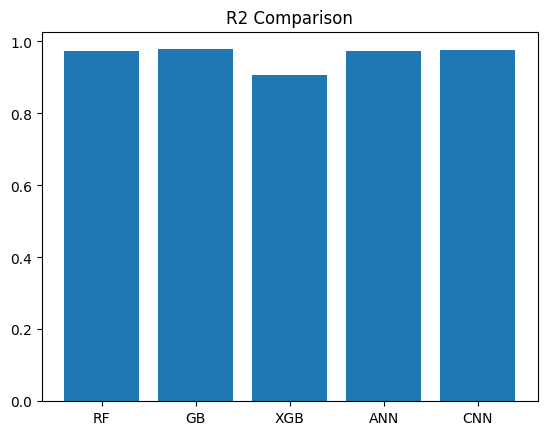

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

results = [
    ["RF", r2_score(y_test,y_pred_rf)],
    ["GB", r2_score(y_test,y_pred_gb)],
    ["XGB", r2_score(y_test,y_pred_xgb)],
    ["ANN", r2_score(y_test,y_pred_ann)],
    ["CNN", r2_score(y_test,y_pred_cnn)]
]

df = pd.DataFrame(results, columns=["Model","R2"])

plt.figure()
plt.bar(df["Model"], df["R2"])
plt.title("R2 Comparison")
plt.show()